# Temporal Convolutional Network - FX Pairs

Does a 60-day temporal convolution improve one-day FX rankings beyond models
that consume a flat feature row? This notebook evaluates a causal, dilated TCN
on the same 61-feature, 20-pair task as the signed linear, GBM, and TabM stages.

**Learning Objectives**:
- Build validation sequences with train-tail context and no validation labels
- Select checkpoints with pooled decision-time rank IC and complete fold coverage
- Distinguish a frozen model vintage from the current fold construction contract
- Interpret a small point estimate using HAC uncertainty and score-scale diagnostics

**Book Reference**: Chapter 13, Sections 13.6 and 13.9

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb),
[`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb), and
[`08_tabular_dl`](08_tabular_dl.ipynb)

In [1]:
"""Temporal convolutional model for one-day FX rankings."""

import hashlib
import json

import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml

import utils.style as style
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.registry import compute_prediction_fold_metrics
from case_studies.utils.sequence_dataset import prepare_fold_sequence_stores
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    ConfigError,
    _replace_temporal_columns,
    load_configs,
    load_modeling_dataset,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
DEVICE = "cpu"
SEED = 42

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = PRIMARY_LABEL or setup["labels"]["primary"]

if setup["labels"]["primary"] != PRIMARY_LABEL:
    raise ConfigError(
        f"{PRIMARY_LABEL!r} has no matching fold-aware temporal artifact. "
        f"Run this notebook with the primary label {setup['labels']['primary']!r}."
    )

print(f"Case study: {CASE_STUDY_ID} | Label: {PRIMARY_LABEL} | Device: {DEVICE}")

Case study: fx_pairs | Label: fwd_ret_1d | Device: cpu


## 1. Load the Current Learning Task

Fold boundaries come from `cv_config.json`, which is also the contract for
fold-aware temporal features. The sealed holdout is neither loaded nor scored.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"

cv_config = json.loads((CASE_DIR / "config" / "cv_config.json").read_text())
splits = generate_cv_splits(
    dataset,
    cv_config=cv_config,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
splits = [
    {
        **split,
        **{
            key: pd.Timestamp(split[key])
            for key in ("train_start", "train_end", "val_start", "val_end")
        },
    }
    for split in splits[: MAX_FOLDS or None]
]

print(f"Dataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Task: {mds.task_type} | Entities: {dataset[entity_col].n_unique()} | Folds: {len(splits)}")
print(f"Latest validation date: {max(split['val_end'] for split in splits).date()}")
print(f"Holdout begins: {pd.Timestamp(setup['evaluation']['holdout_start']).date()}")

Dataset: 77,440 rows x 61 features
Task: regression | Entities: 20 | Folds: 8
Latest validation date: 2023-12-28
Holdout begins: 2024-01-01


## 2. Audit Sequence and Temporal Alignment

Each validation sequence uses the preceding 60 feature rows, including the
train tail for the first validation date. Scaling statistics come only from
training rows. The audit also rejects a temporal feature that is entirely
missing in either side of a fold.

In [5]:
dataset_pd = dataset.to_pandas()
dates = pd.to_datetime(dataset_pd[date_col])

for split in splits:
    train_mask = (dates >= split["train_start"]) & (dates <= split["train_end"])
    val_mask = (dates >= split["val_start"]) & (dates <= split["val_end"])
    train_frame = _replace_temporal_columns(
        dataset_pd,
        train_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    val_frame = _replace_temporal_columns(
        dataset_pd,
        val_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    missing_temporal = [
        name
        for name in mds.temporal_feature_names
        if train_frame[name].isna().all() or val_frame[name].isna().all()
    ]
    if missing_temporal:
        raise ConfigError(
            f"Fold {split['fold']} has no observations for temporal features: {missing_temporal}"
        )

This boundary helper verifies both ends of the first validation sequence: its
target date and the latest feature row observable immediately before it.

In [6]:
def _sequence_boundary(val_store, split):
    first_position = val_store.end_idx[val_store.symbol_idx == 0].min()
    first_prediction_date = pd.Timestamp(val_store.timestamps[0][first_position])
    last_context_date = pd.Timestamp(val_store.timestamps[0][first_position - 1])
    first_symbol = val_store.entities[0]
    expected_context_date = pd.Timestamp(
        dataset_pd.loc[
            (dataset_pd[entity_col] == first_symbol) & (dates < split["val_start"]), date_col
        ].max()
    )
    if first_prediction_date != split["val_start"]:
        raise ConfigError(
            f"Fold {split['fold']} starts at {first_prediction_date}, not {split['val_start']}"
        )
    if last_context_date != expected_context_date:
        raise ConfigError(f"Fold {split['fold']} omits the latest observable context row")
    return first_prediction_date, last_context_date

The sequence audit applies that boundary contract to every fold. Every
validation row must produce one target, including each fold's first day.

In [7]:
fold_audit = []
for split in splits:
    train_mask = (dates >= split["train_start"]) & (dates <= split["train_end"])
    val_mask = (dates >= split["val_start"]) & (dates <= split["val_end"])
    _, val_store, info = prepare_fold_sequence_stores(
        dataset_pd,
        train_mask=train_mask,
        val_mask=val_mask,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        lookback=LOOKBACK,
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        fold_id=split["fold"],
        val_start=split["val_start"],
    )
    first_prediction_date, last_context_date = _sequence_boundary(val_store, split)
    if info["val_sequences"] != int(val_mask.sum()):
        raise ConfigError(f"Fold {split['fold']} dropped validation sequences")
    fold_audit.append(
        {
            "fold": split["fold"],
            "train_sequences": info["train_sequences"],
            "validation_sequences": info["val_sequences"],
            "first_validation_date": first_prediction_date,
            "last_context_date": last_context_date,
        }
    )

pl.DataFrame(fold_audit)

fold,train_sequences,validation_sequences,first_validation_date,last_context_date
i64,i64,i64,datetime[μs],datetime[μs]
0,23640,5420,2015-10-28 00:00:00,2015-10-27 00:00:00
1,24740,5300,2016-11-15 00:00:00,2016-11-14 00:00:00
2,25360,5340,2017-11-27 00:00:00,2017-11-24 00:00:00
3,25720,4600,2018-12-10 00:00:00,2018-12-07 00:00:00
4,24920,5420,2019-10-31 00:00:00,2019-10-30 00:00:00
5,24960,5400,2020-11-18 00:00:00,2020-11-17 00:00:00
6,24940,5320,2021-12-06 00:00:00,2021-12-03 00:00:00
7,24960,5360,2022-12-15 00:00:00,2022-12-14 00:00:00


## 3. Reconstruct or Train the TCN

On a complete registry, the runner rebuilds the selected physical checkpoint
without writing. This frozen v3.0 model predates the current fold and sequence
contract above, so it is evidence for that recorded vintage, not a current-fold
reproduction. A cache miss trains the current contract on deterministic CPU and
uses pooled daily IC to select among complete checkpoints.

In [8]:
dl_configs = [
    config
    for config in load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
    if config["params"].get("architecture") == "tcn"
]
for config in dl_configs:
    config["n_epochs"] = N_EPOCHS
    config["batch_size"] = BATCH_SIZE
    config["params"]["lookback"] = LOOKBACK

if not dl_configs:
    raise ConfigError("No TCN configuration found")

params = dl_configs[0]["params"]
print(
    f"TCN: channels={params['n_channels']}  kernel={params['kernel_size']}  "
    f"dilations={params['dilations']}  dropout={params['dropout']:.1f}"
)
print(f"Budget: {N_EPOCHS} epochs x {len(splits)} folds | Lookback: {LOOKBACK}")

TCN: channels=32  kernel=3  dilations=[1, 2, 4, 8]  dropout=0.1
Budget: 100 epochs x 8 folds | Lookback: 60


In [9]:
def _file_md5(path):
    """Return a compact immutability check for the frozen registry."""
    if not path.exists():
        return None
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "md5").hexdigest()


registry_path = CASE_DIR / "run_log" / "registry.db"
registry_before = _file_md5(registry_path)
result = run_dl_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=dl_configs,
    n_features=len(feature_names),
    device=DEVICE,
    save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="09_dl_tcn",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)
registry_after = _file_md5(registry_path)
frozen_mode = result["training_log"].is_empty() and registry_before is not None
if frozen_mode and registry_after != registry_before:
    raise RuntimeError("The frozen TCN reader path modified registry.db")

vintage = "v3.0 frozen" if frozen_mode else "current CPU"
print(f"Mode: {vintage}")

  SKIP tcn                        (complete (hash=41ccb0845202), split=validation)
All configs already registered - rebuilding result from frozen registry.


Mode: v3.0 frozen


In [10]:
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
predictions = result["predictions"]
curves = result["all_learning_curves"]

headline, _ = compute_prediction_fold_metrics(
    predictions,
    date_col=date_col,
    entity_col=entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    label=label_col,
)
best_ic = float(headline["ic_mean_daily"])

selection_table = pl.DataFrame(result["grid_results"]).select(
    pl.col("config_name").alias("config"),
    pl.col("best_epoch").alias("epoch"),
    pl.col("best_ic").alias("pooled_daily_ic"),
    "ic_n_days",
    "n_invalid",
    "n_folds",
    "selectable",
)
selection_table

config,epoch,pooled_daily_ic,ic_n_days,n_invalid,n_folds,selectable
str,i64,f64,i64,i64,i64,bool
"""tcn""",60,0.009935,2064,0,8,true


The frozen checkpoint contains 2,064 dates, 20 pairs per date, and all eight
historical fold IDs. Its archived learning curve used equal fold means; those
folds each contain 258 dates, so epoch 60 has the same pooled daily IC. The
fresh selector no longer assumes equal fold lengths.

## 4. Comparison with Flat-Feature Baselines

TCN and TabM are nearly tied in this frozen vintage. Their small point-estimate
gap is far below the uncertainty around the TCN result.

In [11]:
baseline_rows = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID]).select(
    "family", "config_name", "ic_mean"
)
baseline_values = {
    "Ridge": float(baseline_rows.filter(pl.col("family") == "linear")["ic_mean"].item()),
    "GBM": float(baseline_rows.filter(pl.col("family") == "gbm")["ic_mean"].item()),
}

tabm_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")
for config in tabm_configs:
    config["n_epochs"] = 100
    config["batch_size"] = 4096
tabm_result = run_tabm_cv(
    pd.DataFrame(),
    splits,
    configs=tabm_configs,
    n_features=len(feature_names),
    feature_names=[],
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    device="cpu",
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
)
if frozen_mode and _file_md5(registry_path) != registry_before:
    raise RuntimeError("Baseline reconstruction modified registry.db")
baseline_values["TabM"] = float(tabm_result["best_ic"])
baseline_values["TCN"] = best_ic

comparison = pl.DataFrame(
    {"model": list(baseline_values), "pooled_daily_ic": list(baseline_values.values())}
).sort("pooled_daily_ic")
comparison

  SKIP tabm_s                     (complete (hash=0fd83d9ab0d4), split=validation)
  SKIP tabm_m                     (complete (hash=a584d604296b), split=validation)
  SKIP tabm_l                     (complete (hash=ff2a113a3bc9), split=validation)
All configs already registered - rebuilding result from frozen registry.


model,pooled_daily_ic
str,f64
"""GBM""",0.002474
"""Ridge""",0.005209
"""TabM""",0.009619
"""TCN""",0.009935


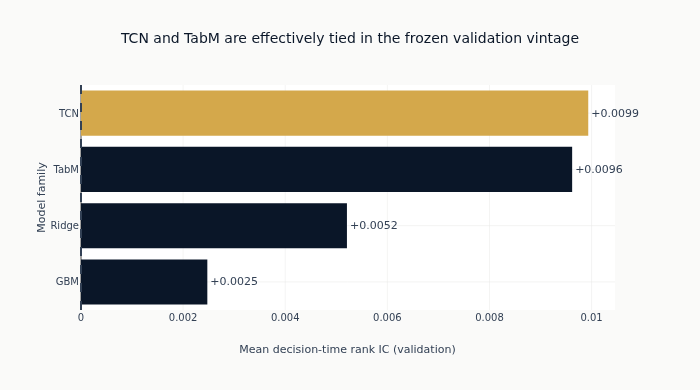

In [12]:
comparison_figure = go.Figure(
    go.Bar(
        x=comparison["pooled_daily_ic"].to_list(),
        y=comparison["model"].to_list(),
        orientation="h",
        marker_color=[
            style.COLORS["amber"] if model == "TCN" else style.COLORS["blue"]
            for model in comparison["model"]
        ],
        text=[f"{value:+.4f}" for value in comparison["pooled_daily_ic"]],
        textposition="outside",
        cliponaxis=False,
    )
)
comparison_figure.add_vline(x=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
comparison_figure.update_layout(
    template="ml4t",
    title="TCN and TabM are effectively tied in the frozen validation vintage",
    xaxis_title="Mean decision-time rank IC (validation)",
    yaxis_title="Model family",
    height=390,
    margin=dict(l=80, r=85, t=85),
    showlegend=False,
)
comparison_figure.show()

## 5. Checkpoint Path

The archived curve is useful as a training diagnostic, but it belongs to the
frozen fold construction. It does not replace a current-contract retrain.

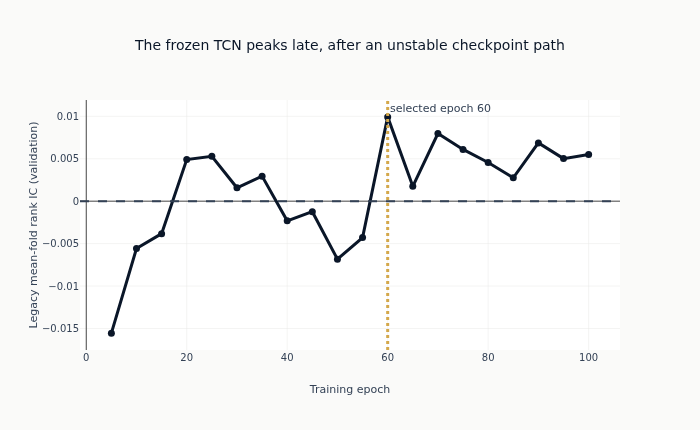

In [13]:
curve = curves.filter(pl.col("config") == best_name).sort("epoch")
curve_figure = go.Figure(
    go.Scatter(
        x=curve["epoch"].to_list(),
        y=curve["ic_mean"].to_list(),
        mode="lines+markers",
        line=dict(color=style.COLORS["blue"], width=3),
        marker=dict(size=7),
        name="TCN",
    )
)
curve_figure.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
curve_figure.add_vline(
    x=best_epoch,
    line=dict(color=style.COLORS["amber"], dash="dot", width=3),
    annotation_text=f"selected epoch {best_epoch}",
    annotation_position="top right",
)
curve_figure.update_layout(
    template="ml4t",
    title="The frozen TCN peaks late, after an unstable checkpoint path",
    xaxis_title="Training epoch",
    yaxis_title="Legacy mean-fold rank IC (validation)",
    height=430,
    showlegend=False,
)
curve_figure.show()

## 6. Uncertainty and Numerical Stability

Daily HAC inference treats dates, not pair-level rows, as observations. Four
folds are negative. Fold 6 also has an extreme score scale: ranking remains
finite, but the raw magnitudes are not suitable for sizing or calibration.

In [14]:
fold_metrics = result["fold_metrics"]
physical_predictions = result["all_predictions"].filter(
    (pl.col("config") == best_name) & (pl.col("epoch") == best_epoch)
)
score_scale = (
    physical_predictions.group_by("fold_id")
    .agg(
        pl.col("y_score").abs().max().alias("max_abs_score"),
        pl.col("y_score").std().alias("score_std"),
        pl.col("y_true").std().alias("target_std"),
    )
    .sort("fold_id")
)

print(f"Selected: {best_name} at epoch {best_epoch} ({vintage})")
print(f"Pooled daily IC: {best_ic:+.4f} across {int(headline['ic_n_days']):,} dates")
print(
    f"HAC 95% CI: [{headline['ic_ci_lo']:+.4f}, {headline['ic_ci_hi']:+.4f}]  "
    f"t={headline['ic_t_hac']:.2f}  p={headline['ic_p_hac']:.3f}  "
    f"lag={int(headline['ic_hac_lag'])}"
)
fold_metrics

Selected: tcn at epoch 60 (v3.0 frozen)
Pooled daily IC: +0.0099 across 2,064 dates
HAC 95% CI: [-0.0033, +0.0231]  t=1.48  p=0.140  lag=7


fold_id,ic_mean,n_test
i64,f64,i64
0,-0.002401,5160
1,-0.001632,5160
2,0.012327,5160
3,-0.008212,5160
4,0.03324,5160
5,0.012048,5160
6,0.043084,5160
7,-0.008976,5160


In [15]:
score_scale

fold_id,max_abs_score,score_std,target_std
i32,f64,f64,f64
0,0.069166,0.017424,0.005285
1,0.100022,0.017158,0.006668
2,0.06515,0.015246,0.00435
3,0.064724,0.014127,0.006099
4,0.052502,0.01292,0.0042
5,0.055885,0.011013,0.004841
6,892.079102,144.365061,0.005049
7,0.128781,0.018965,0.007687


## 7. Result Disposition

The default execution is read-only. It reconstructs the v3.0 TCN result for
reader inspection while keeping the current fold contract visible and tested.
A clean current-contract CPU retrain is a v3.1 measurement task.

In [16]:
print(f"Selected predictions: {predictions.height:,} rows")
print(f"Historical learning checkpoints: {curves.height:,}")
print(f"Registry unchanged: {registry_before == _file_md5(registry_path)}")
print(
    "Current-contract retrain: queued for v3.1" if frozen_mode else "Current-contract run complete"
)

Selected predictions: 41,280 rows
Historical learning checkpoints: 20
Registry unchanged: True
Current-contract retrain: queued for v3.1


## 8. Key Takeaways

1. **The frozen TCN point estimate is small and unresolved.** Epoch 60 reaches
   pooled daily IC +0.0099, with HAC 95% CI [-0.0033, +0.0231] and p=0.140.
2. **TCN does not separate from the simpler TabM baseline.** TabM reaches
   +0.0096 on the same frozen registry, a difference of only +0.0003.
3. **The model is not numerically stable across folds.** Four fold ICs are
   negative, and fold 6 produces extreme raw score magnitudes even though its
   cross-sectional ranks remain finite.
4. **The prior notebook claim of +0.012 overstated this TCN artifact.** Physical
   rows support +0.010 after rounding. Chapter 13's FX comparison uses NLinear,
   not TCN, so this correction does not change the book's conclusion.
5. **A current-contract rerun belongs in v3.1.** The frozen artifact predates
   the explicit fold-aware sequence contract; it is preserved as v3.0 history.

**Next**: [`10_dl_nlinear`](10_dl_nlinear.ipynb) tests whether the simpler
normalize-and-project sequence model provides a more stable FX ranking.